# Curso: Redes Neurais para Processamento de Linguagem Natural

Prof. [Denilson Alves Pereira](https://sites.google.com/ufla.br/denilsonpereira) <br>
Departamento de Ciência da Computação (DCC) <br>
Instituto de Ciências Exatas e Tecnológicas (ICET) <br> 
Universidade Federal de Lavras (UFLA)

# Atividade Prática 03

**Instruções:**
1. Siga os passos indicados em cada célula abaixo para completar a atividade.
2. Você deve inserir código somente entre as linhas marcadas com **INICIE O CÓDIGO AQUI** e **TERMINE O CÓDIGO AQUI**. Há uma indicação de quantas linhas de código são necessárias.
3. Em alguns pontos, confira o resultado esperado conforme marcado com **SAÍDA ESPERADA**.

**Tempo estimado para execução**: 2,0 horas

Versão: Julho, 2024

## O Problema a ser Resolvido

O objetivo da atividade é implementar uma aplicação de busca semântica e um classificador de textos, ambos usando embeddings de documentos obtidos do modelo SentenceBERT (SBERT). Esse modelo é usado para converter os textos de entrada em uma representação numérica por meio dos chamados "embeddings" (ou vetores numéricos n-dimensionais). <br>

Você vai praticar as seguintes habilidades:
- Gerar embeddings de textos usando o modelo SentenceBERT.
- Usar a similaridade do Cosseno para medir a similaridade entre textos.
- Classificar textos de e-commerce em categorias específicas.

Referências: <br>
https://www.sbert.net/ <br>
https://towardsdatascience.com/an-intuitive-explanation-of-sentence-bert-1984d144a868 <br>
https://medium.com/@gulsum.budakoglu/the-rise-of-sentence-bert-a-game-changer-for-semantic-search-1a857c1923aa <br>
https://aclanthology.org/D19-1410.pdf <br>
https://medium.com/@jeremyarancio/semantic-search-using-sequence-bert-2116dabecfa3 <br>
https://www.sbert.net/examples/applications/semantic-search/README.html#util-semantic-search <br>
https://colab.research.google.com/drive/12cn5Oo0v3HfQQ8Tv6-ukgxXSmT3zl35A?usp=sharing <br>

## Geração de Embeddings com o Modelo SentenceBERT

Modelos baseados em Transformers, como BERT e RoBERTa, resolvem diferentes tarefas de PLN por meio da computação de embeddings a nível de palavra. Entretanto, para uma tarefa como a busca semântica, a qual requer um forte entendimento a nível de sentença, usar Transformers a nível de palavra torna-se computacionalmente inviável.

Busca semântica é uma tarefa que envolve encontrar as sentenças (ou documentos compostos por várias sentenças) que são similares, em termos de significado, a uma dada sentença/documento alvo. Comparar pares de sentenças usando Transformers para um grande número de sentenças toma um longo tempo.

SentenceBERT (SBERT) é um modelo gerado a partir de uma modificação na rede padrão do modelo BERT pré-treinado, por meio do uso de Redes Siamesas e a função de perda Triplet, para criar embeddings de sentenças. Esses embeddings podem ser comparados usando a Similaridade do Cosseno ou outra medida de similaridade/distância, tornando a busca semântica para um grande número de sentenças muito rápida.

SentenceBERT modifica o modelo BERT adicionando uma operação de pooling a sua saída, resultando em um embedding de sentença de tamanho fixo.

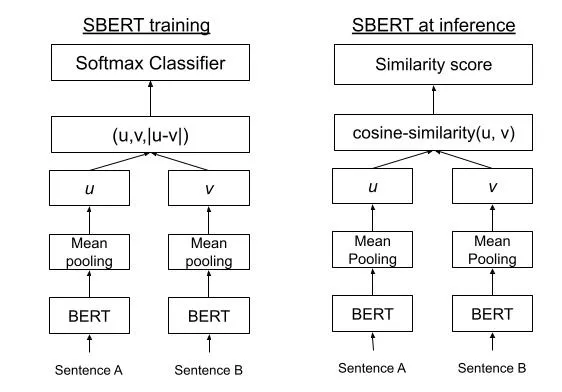

Fonte: https://towardsdatascience.com/an-intuitive-explanation-of-sentence-bert-1984d144a868

Para treinar uma Rede Siamesa, usa-se exemplos de pares de sentenças positivas e negativas. Por exemplo, considere um par com Sentença A e Sentença B, as quais são similares semanticamente. Esse par é então rotulado como exemplo positivo. Outro par com Sentença A e Sentença C, cujas sentenças não são similares, é rotulado como exemplo negativo. A rede usa como objetivo do treinamento a Funçao Triplet, a qual tenta minimizar a distância euclidiana entre Sentença A e Sentença B, pois elas são similares, e maximizar a distância entre Sentença A e Sentença C, pois elas não são similares.

Uma Rede Siamesa contém duas subredes idênticas, onde os dois modelos compartilham os pesos para os parâmetros. A atualização dos parâmetros é espelhada através de ambas as subredes. Após o treinamento, uma nova sentença pode ser codificada simplesmente percorrendo uma das subredes e o seu embedding é obtido na camada de pooling. Esse embedding pode então ser usado para tarefas como busca e classificação, ou seja, pode ser usado como um vetor de features para modelos de aprendizagem de máquina.

A principal diferença entre os modelos BERT e SentenceBERT está na estrutura de seus encoders. BERT usa o Cross Encoder para criar embeddings, enquanto o SentenceBERT usa o Bi-Encoder.

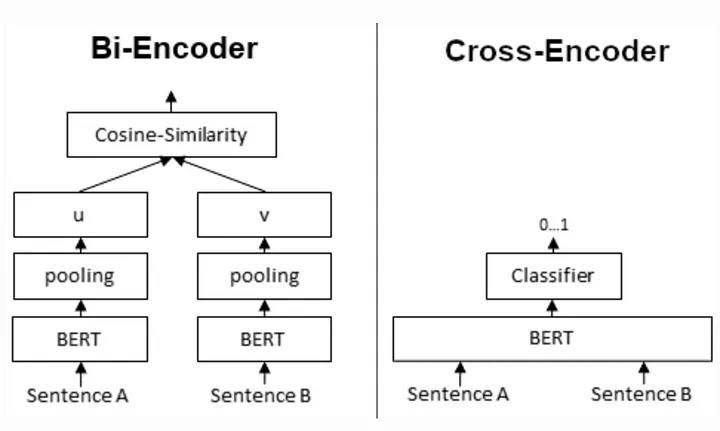
Fonte: https://www.sbert.net/examples/applications/cross-encoder/README.html

Bi-Encoder: os embeddings das sentenças são criados separadamente. No fim da parte de pooling, tem-se dois embeddings de sentenças, u e v. Esses embeddings são usados pela função de similaridade do Cosseno para obter a pontuação de similaridade entre as sentenças.

Cross-Encoder: as sentenças vão para a rede Transformer simultaneamente. A pontuação de similaridade na saída varia entre 0 e 1. O Cross-Encoder não produz uma codificação de sentença, ou seja, não produz um embedding de sentença.

Mais detalhes no artigo: https://aclanthology.org/D19-1410.pdf

## Similaridade do Cosseno

A Similaridade do Cosseno mede a similaridade entre dois vetores A e B pelo cosseno do ângulo formado entre eles. Pra isso, usa-se o conceito de Produto Escalar entre vetores e Norma de vetores.

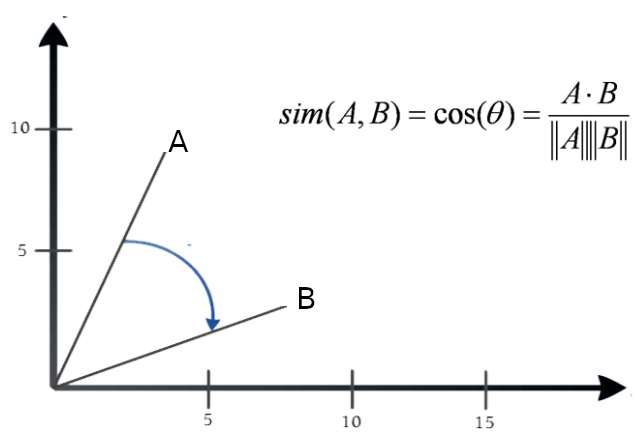

**Produto Escalar** <br>
Considere dois vetores A e B: <br>
$A = (a_1, a_2, \dots, a_n)$ <br>
$B = (b_1, b_2, \dots, b_n)$ <br>
O Produto Escalar entre A e B é dado por: <br>
$ A . B = (a_1 \times b_1) + (a_2 \times b_2) + \dots + (a_n \times b_n)$ <br>

**Norma de um vetor** <br>
Para um vetor V: <br>
$V = (v_1, v_2, \dots, v_n)$ <br>
A Norma de V é dada por: <br>
||V|| = $\sqrt{(v_1)^2 + (v_2)^2 + \dots + (v_n)^2}$

**Similaridade do Cosseno** <br>
A Similaridade do Cosseno entre dois vetores A e B é dada por: <br>
$sim(A,B) = \cos(\theta) = \frac{A . B} {||A|| \times ||B||}$

**Propriedades** <br>
- Valor entre -1 e 1 (geral) <br>
- Valor entre 0 e 1 (em várias aplicações de processamento de linguagem natural) <br>
- $\leq$ 0 (nenhuma similaridade) e 1 (similaridade total)

## Busca Semântica

Dada uma consulta, a busca semântica consiste em encontrar o documento mais similar a essa consulta, ou gerar um ranking (ordenação) dos documentos em ordem decrescente de similaridade com ela.

Um documento pode ser composto por uma única sentença, ou pode ser composto por um texto longo, do tamanho de uma página Web, um artigo científico ou um livro.<br>
No caso do SentenceBERT, o tamanho do texto é limitado pelo tamanho máximo da entrada definida para o modelo BERT, a qual é 512 tokens. Em termos de número de palavras, esse valor é menor, pois cada palavra pode ser dividida em mais de um token.

### Pacotes

In [ ]:
from sentence_transformers import SentenceTransformer, util  # SentenceBERT
import csv

### Dataset

Quora Duplicate Questions dataset - contém aproximadament 500 mil pares de perguntas, obtido de: <br>
https://www.quora.com/q/quoradata/First-Quora-Dataset-Release-Question-Pairs <br>
Os pares de perguntas podem ser ou não duplicados, isto é, representarem a mesma pergunta, porém escritas de formas diferentes. Um dos atributos marca se os pares são duplicados ou não. <br>
As perguntas estão em 100 idiomas diferentes, a maioria em inglês.

Para simplificar, nesta aplicação, vamos usar apenas uma parte do dataset.

In [ ]:
# Lê o dataset
corpus_sentences = set()
dataset_path = "./datasets/quoraDuplicateQuestionsReduced.tsv"
with open(dataset_path, encoding='utf8') as fIn:
    reader = csv.DictReader(fIn, delimiter='\t', quoting=csv.QUOTE_MINIMAL)
    for row in reader:
        corpus_sentences.add(row['question1'])
        corpus_sentences.add(row['question2'])
corpus_sentences = list(corpus_sentences)

### Codificação dos Embeddings

Vários modelos pré-treinados podem ser usados para a codificação. Esta lista de modelos está disponível:<br>
https://www.sbert.net/docs/pretrained_models.html#model-overview

In [ ]:
# modelo multilinguagem usando o DistiBERT
model = SentenceTransformer('quora-distilbert-multilingual')
# codifica as sentenças do corpus de documentos (questions)
print("Codificando os dados. Pode demorar...")
corpus_embeddings = model.encode(corpus_sentences, show_progress_bar=True, convert_to_tensor=True)
print("Dados codificados. Total de {} sentenças/embeddings".format(len(corpus_sentences)))

In [ ]:
### INICIE O CÓDIGO AQUI ### (2 linhas de código)
# imprime o número de elementos (comprimento, dimensão) dos embeddings gerados

# imprime o embedding da primeira sentença

### TERMINE O CÓDIGO AQUI ###

**SAÍDA ESPERADA:** (os números nos vetores podem ser diferentes)<br>

### Função de Busca

Dada uma consulta, a função abaixo pesquisa no corpus e imprime o ranking dos top k resultados (k = 5, no exemplo).

A função "util.semantic_search" implementa uma busca otimizada.<br>
https://www.sbert.net/docs/package_reference/util.html#sentence_transformers.util.semantic_search<br>
Essa função executa a busca pela Similaridade do Cosseno entre uma lista de embeddings de perguntas e uma lista de embeddings do corpus de documentos.<br>
Ela pode ser usada para Recuperação de Informação / Busca Semântica em corpora de até um milhão de entradas. Acima disso, você deve usar uma busca aproximada pelos vizinhos mais próximos (*Approximate Nearest Neighbor*).<br> Uma biblioteca popular para esse tipo de busca é o FAISS.<br>
https://github.com/facebookresearch/faiss

In [ ]:
# Função que busca no corpus e imprime o resultado
# question - lista de consultas
def search(question):
    question_embedding = model.encode(question, convert_to_tensor=True)
    hits = util.semantic_search(question_embedding, corpus_embeddings)
    hits = hits[0]  # obtém o resultado para a primeira consulta

    print("Consulta:", question)
    print("Resultados:")
    for hit in hits[0:5]:
        print("\t{:.3f}\t{}".format(hit['score'], corpus_sentences[hit['corpus_id']]))

### Testes de Busca

In [ ]:
search("How can I learn Python online?")

In [ ]:
search("Como eu posso aprender Python online?")

In [ ]:
# Execute outros testes. Deixe os exemplos abaixo.
### INICIE O CÓDIGO AQUI ### (pelo menos 2 linhas de código)


### TERMINE O CÓDIGO AQUI ###

----------------

## Classificação de Textos usando os Embeddings do Modelo SentenceBERT

A seguir, você vai implementar um exemplo de classificação de textos usando os embeddings gerados pelo modelo SentenceBERT como entrada para um classificador.

### Pacotes

In [ ]:
# Processamento de dados
import pandas as pd
import numpy as np
# Machine Learning
from sentence_transformers import SentenceTransformer  # SentenceBERT
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Data e Hora
from datetime import datetime

### Dataset

Conjunto de dados de e-commerce contendo a categoria e a descrição de cada produto. São 4 categorias de produtos: "Electronics", "Household", "Books" and "Clothing & Accessories".<br>
O dataset completo está disponível em:<br>
https://www.kaggle.com/datasets/saurabhshahane/ecommerce-text-classification<br>
Nesta aplicação, usamos uma versão reduzida do dataset.

In [ ]:
# Dataset a ser classificado
df = pd.read_csv("./datasets/ecommerceDatasetReduced.csv")
df = df[["category", "product"]]

# Exibe os primeiros dados
df.head()

### Análise dos Dados

O dataset contém 5.000 produtos classificadas em 4 categorias

In [ ]:
print('Número total de produtos: {}'.format(len(df)))
print(40*'-')
print('Partição por categoria:')
print(df["category"].value_counts())
print(40*'-')
nr_categories = len(df["category"].unique())
print("Número de categorias: {n}".format(n=nr_categories))

In [ ]:
# Exemplo da categoria n  (modifique o valor de n e verifique)
n=90
print('Categoria: ',df['category'][n])
print(100*'-')
print('Produto:')
print(df['product'][n])

### Codificação dos Embeddings

Gera os embeddings para cada instância de dado usando o modelo SentenceBERT.

In [ ]:
### INICIE O CÓDIGO AQUI ### (2 linhas de código)
# modelo SentenceBERT 'all-MiniLM-L6-v2'


### TERMINE O CÓDIGO AQUI ###

### Partição dos Dados em Treino e Teste

Particiona o dataset em 70% das instâncias para treino e 30% para teste, de forma estratificada, ou seja, mantendo a mesma proporção de dados em cada categoria.



In [ ]:
# Renaming, Input -> X, Output -> y
X = df['embedding'].tolist()
y = df['category']
# Split into Training and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=df['category'])

In [ ]:
# Verifica o percentual de dados de treino
y_train.value_counts()/y.value_counts()

### Treinamento do Classificador

- Usa o classificador Logistic Regression (Regressão Logística).
- Treina o classificador no conjunto de dados de treino, gerando o modelo de predição.

O modelo Logistic Regression é um modelo linear em que o algoritmo de minimização consiste em minimizar um função quadrática em seus parâmetros. O interessante é que essa função não tem mínimos locais, apenas um mínimo global, o qual pode ser alcançado. E pode seer alcançado usando um algoritmo simples e rápido, por meio da inversão de uma matriz do tamanho do vocabulário. A desvantagem é que uma vez que o mínimo é alcançado, é difícil melhorar o modelo (exceto adicionando-se a regularização). Assim, uma vez que o modelo é otimizado, há pouco espaço para melhoramentos.

In [ ]:
### INICIE O CÓDIGO AQUI ### (pelo menos 2 linhas de código)
# Classificador da Regressão Logística

# Treina o classificador gerando o modelo de predição

### TERMINE O CÓDIGO AQUI ###

### Avaliação do Modelo

Avalia o modelo pela métrica 'acurácia", a qual retorna o percentual de acertos do classificador. Para isso, é feita a comparação das predições do modelo com os rótulos do dataset.

A avaliação é feita para ambos os dados de treino e teste. Isso é importante para verificar se não houve *overfitting*, que é um fenômeno que ocorre quando o modelo está fortemente ajustado aos dados de treino. Se a acurácia do treino for muito melhor do que a acurácia do teste, então isso pode indicar a ocorrência de *overfitting*.

Os resultados abaixo indicam que não houve *overfitting*. Caso haja *overfitting*, o modelo pode ser melhorado ajustando-se a regularização (*regularization*), a qual já vem por padrão no modelo de regressão logística. Um mecanismo típico de regularização é a regularização L2.

In [ ]:
# Predição e avaliação nos dados de treino
predicted_train_sbert = model_sbert.predict(X_train)
accuracy_train_sbert = accuracy_score(y_train, predicted_train_sbert)
print('Acurácia nos dados de treino: {:.1%}'.format(accuracy_train_sbert))

# Predição e avaliação nos dados de teste
predicted_test_sbert = model_sbert.predict(X_test)
accuracy_test_sbert = accuracy_score(y_test, predicted_test_sbert)
print('Acurácia nos dados de teste:  {:.1%}'.format(accuracy_test_sbert))

print('Tempo de treinamento: {:.1f}s'.format(training_time_sbert))

**SAÍDA ESPERADA:** (os valores podem ser diferentes)<br>

## Desafio

Troque o classificador de Regressão Logística por outro classificador da sua escolha (ex: SVM, Naive Bayes). Repita os passos para o treinamento e a avaliação do modelo com o novo classificador e compare os resultados.

Adicione abaixo a nova sequência de código.

In [ ]:
### INICIE O CÓDIGO AQUI ### (várias linhas de código / pelo menos 2 células)

In [ ]:
# Classificador xxx

# Treina o classificador gerando o modelo de predição


In [ ]:
# Predição e avaliação nos dados de treino

# Predição e avaliação nos dados de teste


In [ ]:
### TERMINE O CÓDIGO AQUI ###

# Fim

Parabéns! Você efetuou todos os passos para a representação de documentos usando embeddings SentenceBERT. Você aprendeu a usar os embeddings para as tarefas de busca semântica e para classificação de textos.

-------------------------------------------